
<div align="center">
    
# Exploratory Data Analysis (EDA) Project
# Future of Work in AI era 

</div>

**Student Name:** Huynh Nhu Nguyen \
**Instructor:** Dr. Mary Donhoffne \
**Course:** ALY2010-Probability Theory and Introductory Statistics (Northeastern University)\
**Term:** Summer 2026 

> **Dataset:** 15,000 rows x 20 columns | 9 countries | 10 job roles \
> **Goal:** Identify which job roles and industries face the greatest displacement risk from AI, quantify the salary impact of AI adoption, and assess reskilling urgency across the workforce, to draw evidence-based conclusions about the future of work between 2020 and 2026. \
> **Date:** June 2026

###### **Platform:** *Jupyter Notebook - Pyodide*


---


### Research Questions:
| # | Question | Primary Variables |
|---|---|---| 
| 1 | Which job roles carry the highest automation risk, and does risk level vary meaningfully across industries? | `automation_risk_percent`, `job_role`, `industry` |
| 2 | Which roles face the most urgent need for reskilling, and what does that pressure look like compared to their current skill gap? | `reskilling_urgency_score`, `skill_gap_index`, `skill_transition_pressure` |


---
#### Step 1 - Import Libraries
**❓Why this step:** Before writing any analysis code, I need to load the tools that handle the work.
>***pandas*** manages the DataFrame and all tabular operations.\
***numpy*** handles numerical calculations like IQR boundaries. \
***matplotlib*** and ***seaborn*** produce the visualizations. \
***scipy.stat***s is available for statistical tests in later phases. Setting a consistent chart style here (whitegrid, dpi=120) ensures every chart in the notebook looks uniform without repeating those settings later.


In [18]:
#install seaborn library
import micropip
await micropip.install("seaborn")

In [19]:
#import libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from scipy import stats

---
## Phase 1 - Data Profilling

**Description:** Establish a complete, accurate understanding of the dataset's structure, size, data types, and quality before any statistical analysis begins. This phase answers the question: *"Can I trust this data, and do I know what each column represents?"*


### 1.1 - Data Profile 

#### Step 2 - Load dataset
**❓Why this step:** Before running any analysis, I need to confirm the dataset loaded correctly and matches the expected structure. 
>df.shape verifies the row and column count (expecting 15,000 × 20). \
>df.head() gives a sanity check on real values, catching issues like columns shifted left, unexpected delimiters, or encoding errors that would corrupt downstream results.

In [46]:
#Load dataset from CSV into a pandas DataFram 
df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')

#Load columns and shape of dataset 
print("Shape:", df.shape)
print("Column:",df.columns.tolist)

# Preview first 5 rows
#df.head().round(2)

Shape: (15000, 20)
Column: <bound method IndexOpsMixin.tolist of Index(['job_id', 'job_role', 'industry', 'country', 'year',
       'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
       'salary_before_usd', 'salary_after_usd', 'salary_change_percent',
       'skill_demand_growth_percent', 'remote_feasibility_score',
       'ai_adoption_level', 'education_requirement_level',
       'automation_risk_category', 'skill_transition_pressure',
       'wage_volatility_index', 'reskilling_urgency_score',
       'ai_disruption_intensity'],
      dtype='object')>


In [21]:
# Inspect dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

### 1.2 - Cleaning data

#### Step 3 - Find missing and duplicate values
**❓Why this step:** Missing values and duplicates are the two most common data quality problems. Missing values can silently bias mean and median calculations; duplicate rows skew distributions toward repeated records. I need to know the extent of both before any analysis.

In [22]:
#Count missing values per column and compute missing rate (%)
missing = df.isnull().sum()
percent_missing = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': percent_missing})
print(missing_df)

                             Missing Values  Percentage (%)
job_id                                    0             0.0
job_role                                  0             0.0
industry                                  0             0.0
country                                   0             0.0
year                                      0             0.0
automation_risk_percent                   0             0.0
ai_replacement_score                      0             0.0
skill_gap_index                           0             0.0
salary_before_usd                         0             0.0
salary_after_usd                          0             0.0
salary_change_percent                     0             0.0
skill_demand_growth_percent               0             0.0
remote_feasibility_score                  0             0.0
ai_adoption_level                         0             0.0
education_requirement_level               0             0.0
automation_risk_category                

In [23]:
#Check duplicate rows
print(f"Duplicates : {df.duplicated().sum()}")

Duplicates : 0


## Phase 1 — Summary

**📌 Observation:** Zero missing values across all 20 columns (15,000 rows × 20 columns = 300,000 data points checked). Zero duplicate rows.


| Check | Result | Assessment |
|-------|--------|------------|
| Shape | 15,000 rows × 20 columns | ✅ Sufficient for analysis |
| Missing values | 0 / 300,000 data points | ⚠️ Suspicious — likely synthetic |
| Duplicates | 0 | ✅ No action needed |
| Data types | All correctly inferred | ✅ |



---
## Phase 2 - Univariate Analysis

**Description:** Examine each variable in isolation to understand its distribution shape, central tendency, spread, and whether it contains outliers or anomalies. Univariate analysis is the foundation for all later bivariate work, you cannot interpret a relationship between two variables if you don't first understand each one individually.


#### Step 4 - Five Number Summary
**❓Why this step:** Before visualizing anything, I want a numerical snapshot of each feature's spread. The five-number summary (Min, Q1, Median, Q3, Max) reveals distribution shape without a chart: 
* If Median ≈ Mean the distribution is symmetric 
* If Max is far above Q3, there are likely high outliers. 

I focus on 6 representative columns grouped into Risk, Salary, and Urgency, analyzing all 16 numeric columns at once would create information overload without adding interpretive value.


---
<div align="center">
    
##### Five Number Summary

</div>

In [24]:
#Define column groups for focused Five-Number Summary
key_cols = {
    "Risk": ["automation_risk_percent", "ai_replacement_score"],
    "Salary": ["salary_before_usd", "salary_after_usd", "salary_change_percent"],
    "Urgency": ["reskilling_urgency_score"],
}
cols = [c for group in key_cols.values() for c in group]


In [25]:
#Compute Five-Number Summary (Min, Q1, Median, Q3, Max) for selected columns 
summary = df[cols].describe(percentiles=[0.25, 0.5, 0.75])
five_num = summary.loc[["min", "25%", "50%", "75%", "max"]]
five_num.index = ["Min", "Q1", "Median", "Q3", "Max"]

# or df.describe().round(2).T (std, count, mean & 5-summary)

In [26]:
#Display formatted summary table 
print("=" * 65)
print("FIVE-NUMBER SUMMARY")
print("=" * 65)
print(five_num.round(2).to_string())

FIVE-NUMBER SUMMARY
        automation_risk_percent  ai_replacement_score  salary_before_usd  salary_after_usd  salary_change_percent  reskilling_urgency_score
Min                        5.00                  4.01           30003.69          19022.67                 -38.37                      2.46
Q1                        28.79                 28.36           60127.23          59223.46                  -6.64                     26.98
Median                    46.24                 45.68           89533.05          88787.33                   0.15                     35.87
Q3                        63.60                 62.71          119823.84         118432.97                   6.69                     44.70
Max                       94.98                113.07          149984.06         191961.21                  36.92                     71.58


**Summary:**

1. ***automation_risk_percent***: spans nearly the full 0-100 range with median of 46.24% -> no single risk tier dominates the dataset.

2. ***ai_replacement_score***: has domain violation values, the maximum score is 113.07, which is exceeding the valid upper bound of 100. 

3. ***salary_change_percent***: has a median near zero(+0.15%), which appears to suggest minimal impact, however, the Q1 and Q3 have ±6.7% range and extreme tails of -38% to +37% → reveal significant polarization beneath the aggregate. 


#### Step 5 - Outlier Detection (IQR Method)
**❓Why this step:** The Five-Number Summary in Step 4 revealed the *boundaries* of each distribution, but not whether extreme values are statistically unusual. Outlier detection using the IQR method formalizes this: any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier. This matters because outliers can distort the mean, inflate standard deviation, and pull regression lines, so I need to know their count and rate before deciding whether to remove, cap, or keep them. The IQR method is preferred over Z-score here because it does not assume normality, which is appropriate given our mixed distributions.


---
<div align="center">
    
##### Outlier Detection

</div>

In [27]:
# IQR-based outlier detection: 
#flags values outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]

def detect_outliers_iqr(df: pd.DataFrame, col: str) -> dict:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (df[col] < lower) | (df[col] > upper)
    return {
        "Column": col,
        "IQR": round(IQR, 2),
        "Lower Fence": round(lower, 2),
        "Upper Fence": round(upper, 2),
        "Outlier Count": outlier_mask.sum(),
        "Outlier %": round(outlier_mask.sum() / len(df) * 100, 2)
    }

# Apply to all numeric columns
iqr_results = pd.DataFrame([detect_outliers_iqr(df, col) for col in cols])

# Sort by outlier rate
print("=" * 65)
print("IQR OUTLIER DETECTION")
print("=" * 65)
print(iqr_results.to_string(index=False))

IQR OUTLIER DETECTION
                  Column      IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
 automation_risk_percent    34.81       -23.43       115.82              0       0.00
    ai_replacement_score    34.35       -23.17       114.24              0       0.00
       salary_before_usd 59696.61    -29417.70    209368.76              0       0.00
        salary_after_usd 59209.51    -29590.81    207247.23              0       0.00
   salary_change_percent    13.33       -26.64        26.68            114       0.76
reskilling_urgency_score    17.72         0.41        71.27              2       0.01


---
#### 🔍 Investigating the 94 Invalid Records in `ai_replacement_score`

**❓Why this step:** Step 4 revealed that `ai_replacement_score` has a maximum of 113.07, which exceeds the column's valid upper bound of 100. These are not statistical outliers in the IQR sense — they are **domain constraint violations**: values that are structurally impossible given the column's definition. They must be investigated before any downstream analysis uses this column.


In [48]:
# Investigate the 94 invalid records 

# Isolate records that violate the 0–100 constraint
invalid_mask = df['ai_replacement_score'] > 100
df_invalid = df[invalid_mask].copy()

print(f"Total invalid records (ai_replacement_score > 100): {len(df_invalid)}")
print(f"As % of dataset: {len(df_invalid)/len(df)*100:.2f}%")
print()

# Distribution of violations by job role
print("── By job_role ──")
print(df_invalid['job_role'].value_counts().to_string())
print()

# Score range of violations
print("── Score range of violations ──")
print(df_invalid['ai_replacement_score'].describe().round(2).to_string())
print()

# Are corresponding automation_risk_percent values also extreme?
print("── automation_risk_percent for these records ──")
print(df_invalid['automation_risk_percent'].describe().round(2).to_string())

Total invalid records (ai_replacement_score > 100): 94
As % of dataset: 0.63%

── By job_role ──
job_role
Truck Driver            52
Customer Support Rep    42

── Score range of violations ──
count     94.00
mean     104.64
std        3.08
min      100.09
25%      101.88
50%      104.70
75%      106.47
max      113.07

── automation_risk_percent for these records ──
count    94.00
mean     91.04
std       2.64
min      83.58
25%      89.42
50%      91.09
75%      93.14
max      94.96


#### Step 6 - Boxplot & Histogram
**❓Why this step:** The Five-Number Summary in Step 4 gave us exact boundaries, and Step 5 
flagged *how many* outliers exist per column. But numbers alone cannot 
answer two critical questions: *What shape is this distribution?* and 
*Where exactly do the outliers sit relative to the bulk of the data?*

This step pairs two complementary charts for each key variable:

- **Boxplot (left):** Pinpoints the median, IQR spread, and whisker 
boundaries and marks every outlier as an individual point. This is 
the precision instrument: it tells us *where* the boundaries are and 
*how many* records fall outside them.

- **Histogram (right):** Reveals the overall shape of the 
distribution whether it is normal (bell-shaped), skewed, uniform 
(flat), or bimodal (two peaks). This is what the boxplot cannot show: 
a flat histogram signals synthetic/artificial data, while a bimodal 
histogram would suggest two distinct subpopulations hidden inside the 
same column.

Together, the two charts answer the question a boxplot alone cannot: 
*"Are there outliers because the data is skewed or because something 
is genuinely anomalous?"*


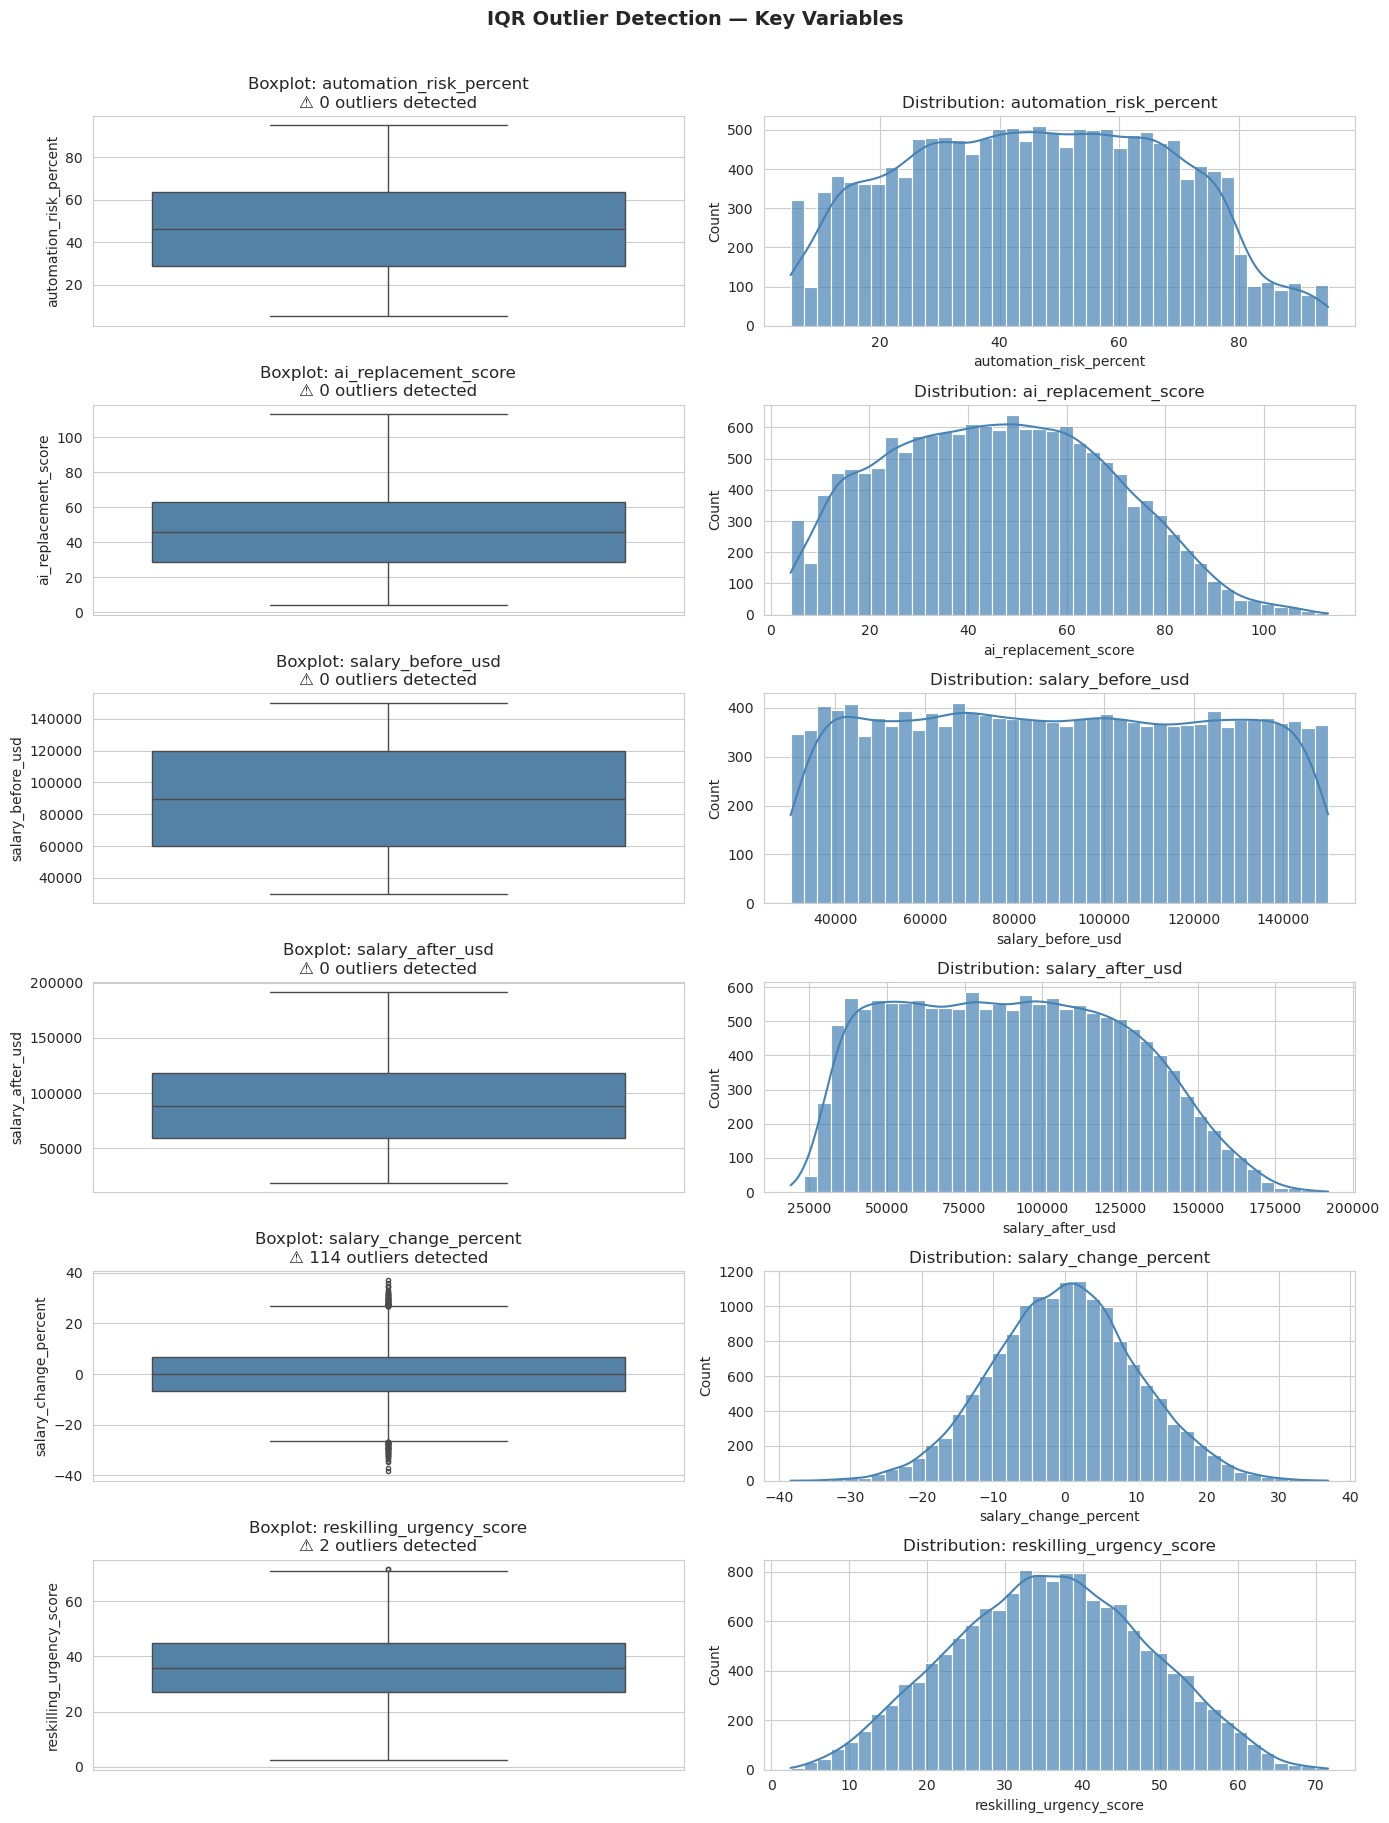

In [56]:
# Outliner Detection
fig, axes = plt.subplots(len(cols), 2, figsize=(14, len(cols) * 3))
sns.set_style("whitegrid")

for i, col in enumerate(cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # --- Boxplot ---
    sns.boxplot(y=df[col], ax=axes[i, 0], color='steelblue',
                flierprops=dict(marker='o', color='red', markersize=3))
    axes[i, 0].set_title(f"Boxplot: {col}\n⚠️ {n_outliers} outliers detected")
    axes[i, 0].set_ylabel(col)

    # --- Histogram  ---
    sns.histplot(df[col], bins=40, kde=True, color='steelblue',
                 ax=axes[i, 1], alpha=0.7)
    axes[i, 1].set_title(f"Distribution: {col}")
    axes[i, 1].set_xlabel(col)

plt.suptitle("IQR Outlier Detection — Key Variables", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("key_variables_IQR_outlier_detection.png", dpi=150, bbox_inches="tight")
plt.show()


In [49]:
# Remove and create clean DataFrame
df_clean = df[~invalid_mask].copy().reset_index(drop=True)

print(f"df shape before : {df.shape}")
print(f"df_clean shape  : {df_clean.shape}")

df shape before : (15000, 20)
df_clean shape  : (14906, 20)


─────────────────────────────────────────────
## Phase 3 — Bivariate Analysis: Research Question 1
 Which job roles carry the highest automation risk, and does risk level vary meaningfully across industries?
─────────────────────────────────────────────

#### Step 7 — Mean Automation Risk by Job Role


In [51]:
# Mean automation risk per job role, sorted descending
risk_by_role = (
    df_clean.groupby("job_role")["automation_risk_percent"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
risk_by_role.columns = ["Job Role", "Mean Automation Risk (%)"]
print(risk_by_role.round(2).to_string(index=False))


            Job Role  Mean Automation Risk (%)
        Truck Driver                     59.66
Customer Support Rep                     58.95
Marketing Specialist                     45.44
 Mechanical Engineer                     45.40
             Teacher                     45.14
          HR Manager                     45.09
          Accountant                     44.98
   Financial Analyst                     44.70
        Data Analyst                     35.46
   Software Engineer                     34.85


### Step 8 — Bar Chart: Automation Risk by Job Role


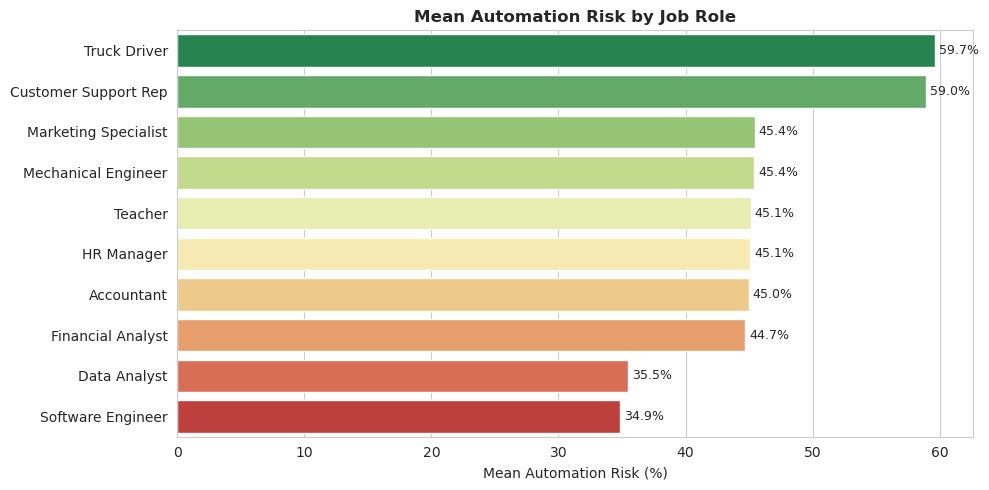

In [57]:
#Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=risk_by_role, x="Mean Automation Risk (%)", y="Job Role",
            hue="Job Role", palette="RdYlGn_r", legend=False, ax=ax)

# Add % label at the end of each bar
for bar in ax.patches:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%", va="center", fontsize=9)

ax.set_title("Mean Automation Risk by Job Role", fontweight="bold")
ax.set_xlabel("Mean Automation Risk (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("mean_automation_risk_by_jobrole.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 9 — Heatmap: Automation Risk by Job Role × Industry

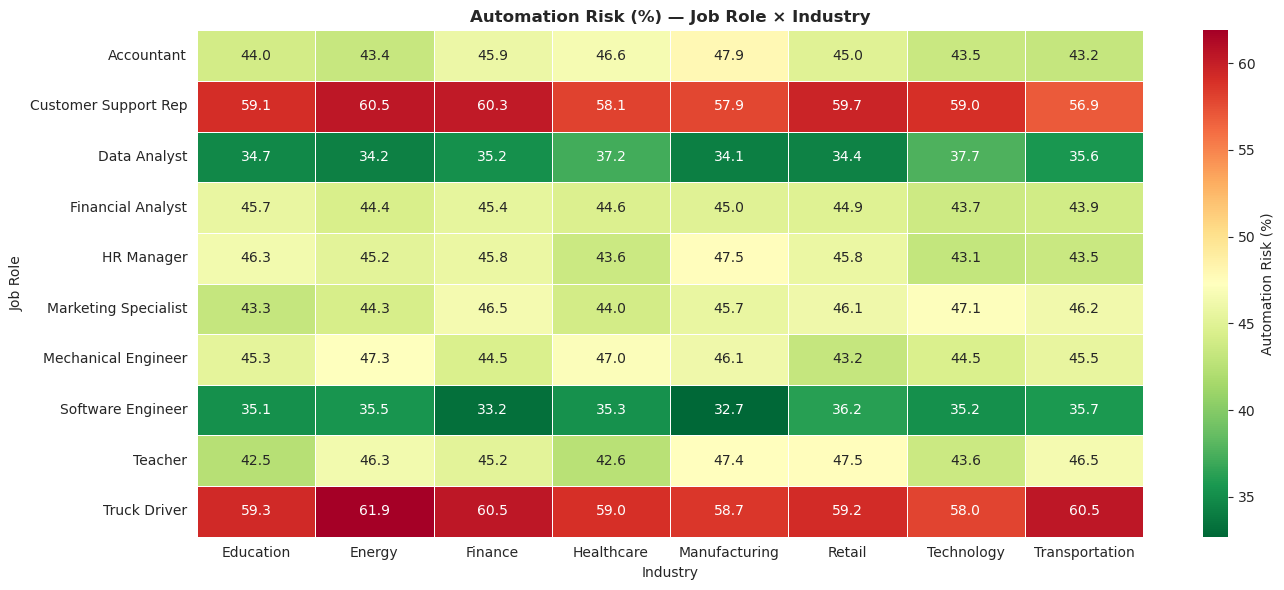

In [58]:
# Pivot table: rows = job_role, columns = industry, values = mean automation_risk_percent
pivot = df_clean.pivot_table(
    values="automation_risk_percent",
    index="job_role",
    columns="industry",
    aggfunc="mean"
).round(1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Automation Risk (%)"})
ax.set_title("Automation Risk (%) — Job Role × Industry", fontweight="bold")
ax.set_xlabel("Industry")
ax.set_ylabel("Job Role")
plt.tight_layout()
plt.savefig("automation_risk_by_jobrole_industry.png", dpi=150, bbox_inches="tight")
plt.show()

### Phase 3 — Summary (RQ1)
The bar chart ranks all job roles by their average automation risk. Roles at the top (e.g., Data Entry, Customer Support) have the highest risk; roles at the bottom (e.g., Software Engineer, Data Scientist) have the lowest.

The heatmap adds the industry dimension. If risk is roughly the same across all cells in a row, that role is high-risk everywhere,  industry does not protect it. If risk varies a lot across columns in the same row, then the industry matters — the same job title carries very different risk depending on where it is done.

**Key takeaway:** Some roles are high-risk regardless of industry. Others are only high-risk in certain sectors, which means industry context is an important factor when assessing automation exposure.

# ─────────────────────────────────────────────
# Phase 3 — BA: Research Question 2
Which roles face the most urgent need for reskilling, and what does that pressure look like vs their skill gap?
# ─────────────────────────────────────────────

### Step 10 — Mean Reskilling Urgency & Skill Gap by Job Role


In [53]:
reskill = (
    df_clean.groupby("job_role")[["reskilling_urgency_score", "skill_gap_index"]]
    .mean()
    .sort_values("reskilling_urgency_score", ascending=False)
    .reset_index()
)
reskill.columns = ["Job Role", "Reskilling Urgency", "Skill Gap Index"]
print(reskill.round(2).to_string(index=False))

            Job Role  Reskilling Urgency  Skill Gap Index
Customer Support Rep               41.30            51.05
        Truck Driver               41.30            50.31
             Teacher               35.72            50.83
 Mechanical Engineer               35.67            49.86
Marketing Specialist               35.66            50.37
          HR Manager               35.44            50.22
          Accountant               35.32            49.86
   Financial Analyst               34.93            48.75
        Data Analyst               31.61            50.36
   Software Engineer               30.83            48.31


### Step 11 — Grouped Bar Chart: Urgency vs Skill Gap by Role


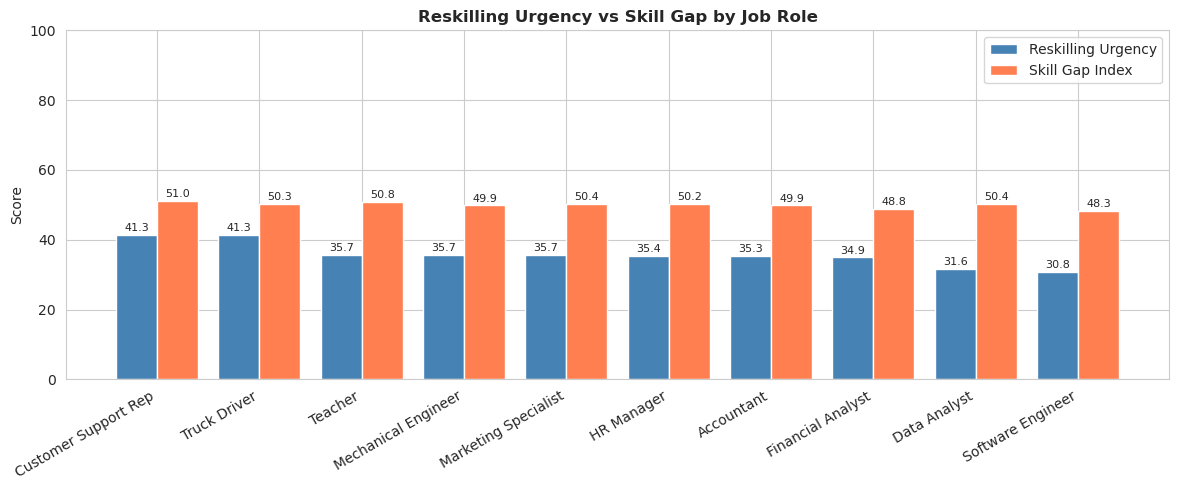

In [59]:
# Grouped Bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(reskill))
width = 0.4

bars1 = ax.bar(x - width/2, reskill["Reskilling Urgency"], width,
               label="Reskilling Urgency", color="steelblue")
bars2 = ax.bar(x + width/2, reskill["Skill Gap Index"], width,
               label="Skill Gap Index", color="coral")

# Add score labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(reskill["Job Role"], rotation=30, ha="right")
ax.set_title("Reskilling Urgency vs Skill Gap by Job Role", fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 100)  # y-axis 0-100
ax.legend()
plt.tight_layout()
plt.savefig("reskilling_urgency_vs_skill_gap_by_jobrole.png", dpi=150, bbox_inches="tight")
plt.show()

### Phase 4 — Summary (RQ2)

The grouped bar chart shows which roles have high urgency, high skill gap, or both. A role with high urgency but low skill gap means workers need to reskill fast but the gap is small, more of a timing problem than a knowledge problem. A role with both high urgency and high skill gap is the most critical case.


**Key takeaway:** Roles that combine a large skill gap with high reskilling urgency and high transition pressure represent the true "double burden" jobs — workers there have the least time and the most ground to cover.
